In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
plt.rcParams.update({'font.size': 16})
plt.rcParams["font.family"]="Times New Roman"

In [2]:
df = pd.DataFrame(
[item.split("\t") for item in """25	SNSE-sequential	42	6
25	SNSE-parallel	10	7
25	SNME	7	8
25	MNME	4	13
50	SNSE-sequential	80	12
50	SNSE-parallel	10	14
50	SNME	13	16
50	MNME	5	14
100	SNSE-sequential	152	22
100	SNSE-parallel	11	34
100	SNME	24	28
100	MNME	7	22
250	SNSE-sequential	370	55
250	SNSE-parallel	15	107
250	SNME	64	75
250	MNME	17	50""".split("\n")]
, columns=["No. of entities","Strategy","Processing Time (hours)", "Cost ($)"])
df["No. of entities"] = df["No. of entities"].apply(lambda x: str(x.strip()))
df["Processing Time (hours)"] = df["Processing Time (hours)"].apply(lambda x: np.nan if str(x)=='' else x).astype(float)
df["Cost ($)"] = df["Cost ($)"].apply(lambda x: np.nan if str(x)=='' else x).astype(float)
# df["Processing Time (sec) in log10"] = np.log10(df["Processing Time (sec)"])
# df["Processing Time (hours)"] = df["Processing Time (sec)"]/3600
df

,No. of entities,Strategy,Processing Time (hours),Cost ($)
0,25,SNSE-sequential,42.0,6.0
1,25,SNSE-parallel,10.0,7.0
2,25,SNME,7.0,8.0
3,25,MNME,4.0,13.0
4,50,SNSE-sequential,80.0,12.0
5,50,SNSE-parallel,10.0,14.0
6,50,SNME,13.0,16.0
7,50,MNME,5.0,14.0
8,100,SNSE-sequential,152.0,22.0
9,100,SNSE-parallel,11.0,34.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   No. of entities          16 non-null     object 
 1   Strategy                 16 non-null     object 
 2   Processing Time (hours)  16 non-null     float64
 3   Cost ($)                 16 non-null     float64
dtypes: float64(2), object(2)
memory usage: 640.0+ bytes


<Axes: xlabel='No. of entities', ylabel='Cost ($)'>

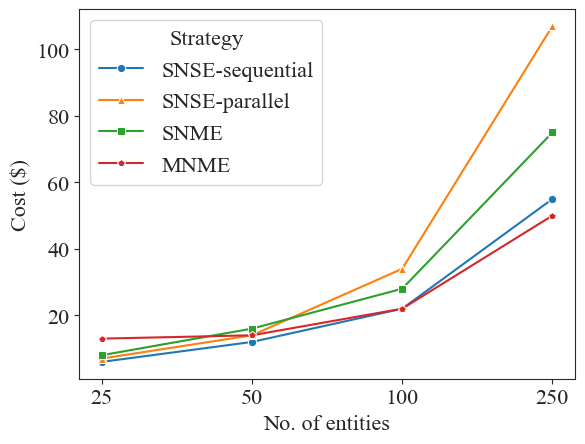

In [4]:
sns.lineplot(data=df, x="No. of entities", y="Cost ($)", hue="Strategy", 
             markers=["o", "^", "s", "p"], 
             dashes=False, style="Strategy")

<Axes: xlabel='No. of entities', ylabel='Processing Time (hours)'>

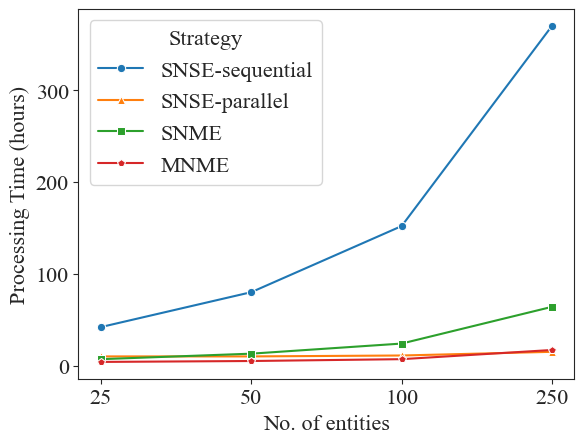

In [5]:
sns.lineplot(data=df, x="No. of entities", y="Processing Time (hours)", hue="Strategy", 
             markers=["o", "^", "s", "p"], 
             dashes=False, style="Strategy")

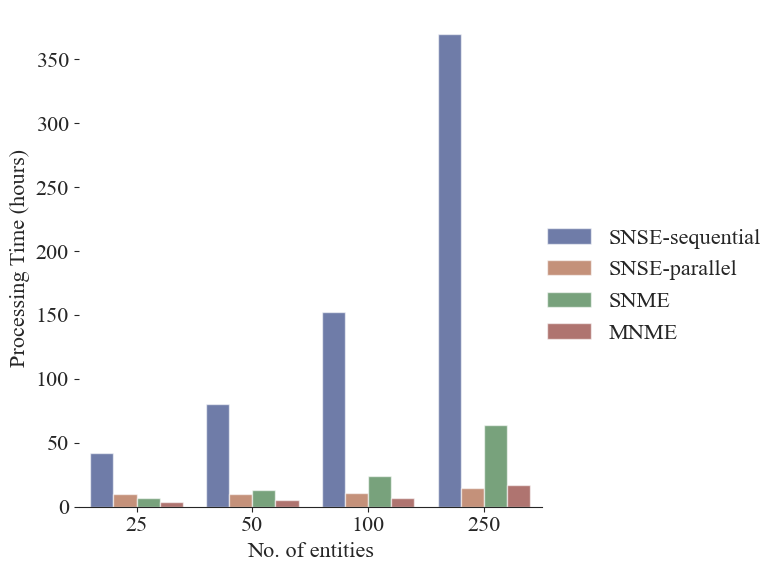

In [22]:
g = sns.catplot(
    data=df, kind="bar",
    x="No. of entities", y="Processing Time (hours)", 
    hue="Strategy", palette="dark", alpha=.6, height=6,
)
g.despine(left=True)
g.set_axis_labels("No. of entities", "Processing Time (hours)")
g.legend.set_title("")

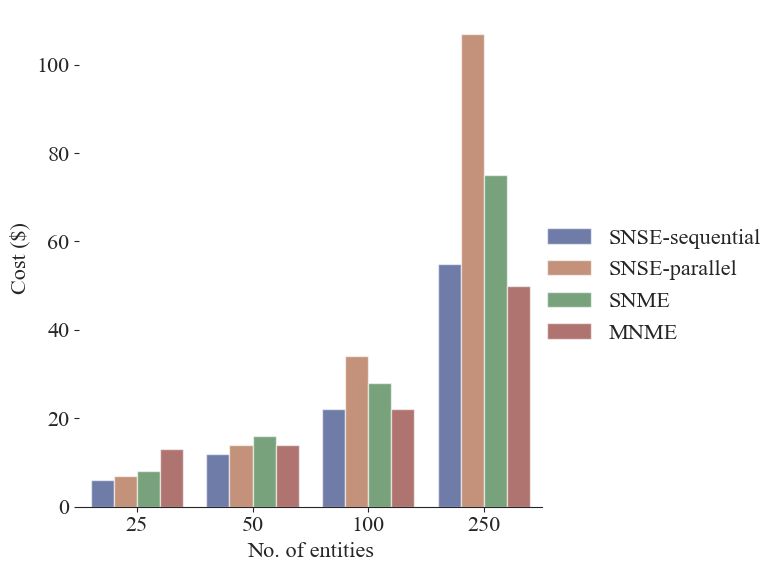

In [23]:
g = sns.catplot(
    data=df, kind="bar",
    x="No. of entities", y="Cost ($)", 
    hue="Strategy", palette="dark", alpha=.6, height=6,
)
g.despine(left=True)
g.set_axis_labels("No. of entities", "Cost ($)")
g.legend.set_title("")

Text(0, 0.5, 'Cost ($)')

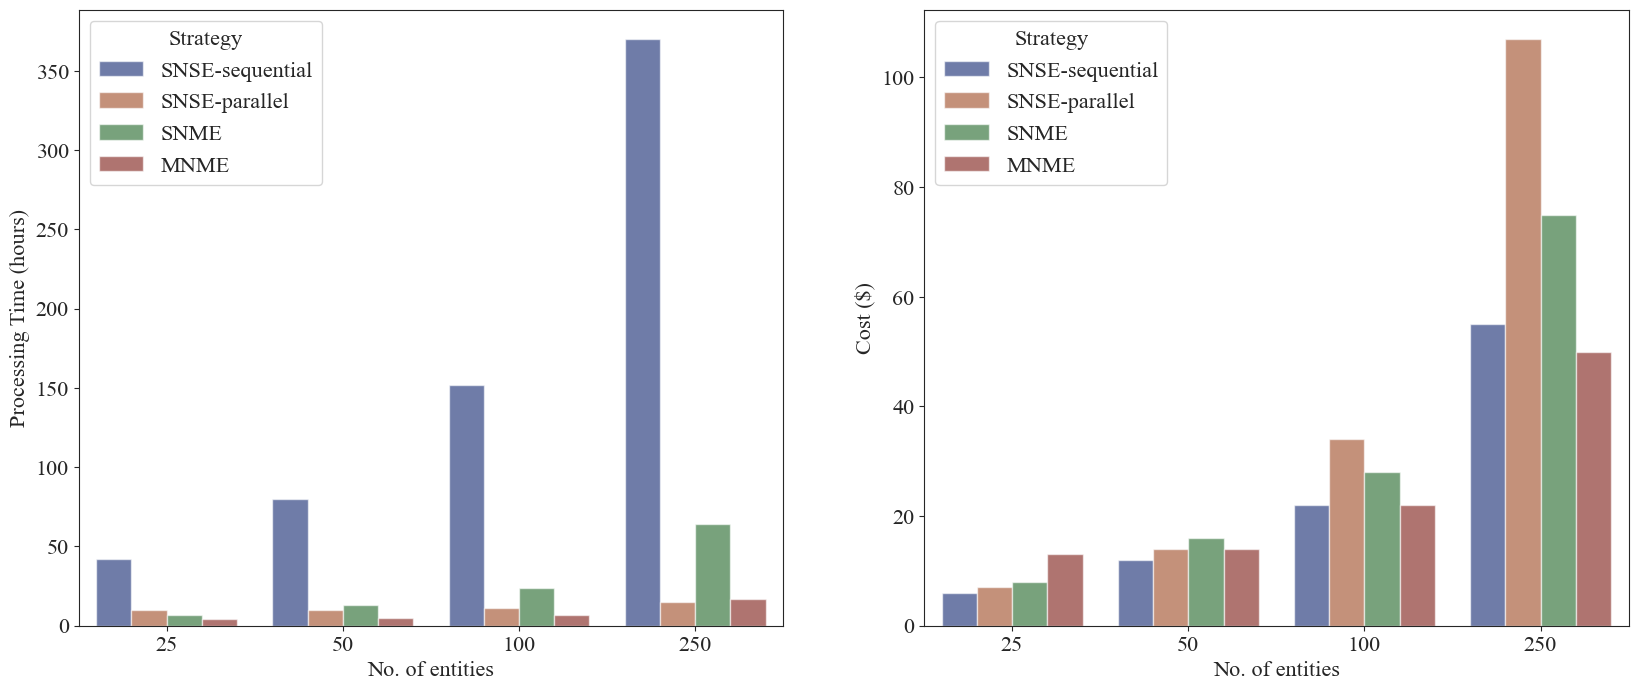

In [33]:
fig, axs = plt.subplots(ncols=2, figsize=(20,8))

g = sns.barplot(
    data=df,
    x="No. of entities", y="Processing Time (hours)", 
    hue="Strategy", palette="dark", alpha=.6,
    ax=axs[0]
)
g.set_xlabel("No. of entities")
g.set_ylabel("Processing Time (hours)")

h = sns.barplot(
    data=df, 
    x="No. of entities", y="Cost ($)", 
    hue="Strategy", palette="dark", alpha=.6,
    ax=axs[1]
)
h.set_xlabel("No. of entities")
h.set_ylabel("Cost ($)")